Verify NVIDIA GPU Availability

In [1]:
!nvidia-smi

Sat Mar 21 03:14:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Unzip images to a custom data folder

In [2]:
!unzip -q /content/data.zip -d /content/custom_data

Split images into train and validation folders

In [3]:
!wget -O /content/train_val_split.py https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py

!python train_val_split.py --datapath="/content/custom_data/data/images" --train_pct=0.9

--2026-03-21 03:14:37--  https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3203 (3.1K) [text/plain]
Saving to: ‘/content/train_val_split.py’

/content/train_val_ 100%[===================>]   3.13K  --.-KB/s    in 0s      

2026-03-21 03:14:37 (46.7 MB/s) - ‘/content/train_val_split.py’ saved [3203/3203]

Created folder at /content/data/train/images.
Created folder at /content/data/train/labels.
Created folder at /content/data/validation/images.
Created folder at /content/data/validation/labels.
Number of image files: 0
Number of annotation files: 0
Images moving to train: 0
Images moving to validation: 0


In [4]:
import os
import glob
import random
import shutil

source_path = '/content/custom_data/data'
train_path = '/content/yolo_data/train'
val_path = '/content/yolo_data/val'

for p in [train_path, val_path]:
    os.makedirs(os.path.join(p, 'images'), exist_ok=True)
    os.makedirs(os.path.join(p, 'labels'), exist_ok=True)

image_exts = ['*.png', '*.jpg', '*.jpeg', '*.JPG', '*.PNG']
images = []
for ext in image_exts:
    images.extend(glob.glob(os.path.join(source_path, 'images', ext)))

random.shuffle(images)
split_idx = int(len(images) * 0.9)
train_files = images[:split_idx]
val_files = images[split_idx:]

def move_files(file_list, target_dir):
    for img_path in file_list:
        file_name = os.path.basename(img_path)
        base_name = os.path.splitext(file_name)[0]

        shutil.copy(img_path, os.path.join(target_dir, 'images', file_name))

        label_path = os.path.join(source_path, 'labels', base_name + '.txt')
        if os.path.exists(label_path):
            shutil.copy(label_path, os.path.join(target_dir, 'labels', base_name + '.txt'))

move_files(train_files, train_path)
move_files(val_files, val_path)

print(f"Done! Sent {len(train_files)} to training and {len(val_files)} to validation.")

Done! Sent 418 to training and 47 to validation.


install the Ultralytics

In [5]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.3 MB/s eta 0:00:00


Configure Training

In [8]:
import yaml

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):

  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found at {path_to_classes_txt}')
    return

  with open(path_to_classes_txt, 'r') as f:
    classes = [line.strip() for line in f.readlines() if line.strip()]

  number_of_classes = len(classes)

  data = {
      'path': '/content/yolo_data',
      'train': 'train/images',
      'val': 'val/images',
      'nc': number_of_classes,
      'names': classes
  }

  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)

  print(f'Created config file at {path_to_data_yaml}')

path_to_classes_txt = '/content/custom_data/data/classes.txt'
path_to_data_yaml = '/content/data.yaml'
create_data_yaml(path_to_classes_txt, path_to_data_yaml)

print('\nNew File contents:\n')
!cat /content/data.yaml

Created config file at /content/data.yaml

New File contents:

path: /content/yolo_data
train: train/images
val: val/images
nc: 1
names:
- Pothole


 Run Training

In [9]:
!yolo detect train data=/content/data.yaml model=yolov8s.pt epochs=40 imgsz=640

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, i

Test Model

In [15]:
!find /content/runs -name "best.pt"

/content/runs/detect/train/weights/best.pt


In [16]:
!yolo detect predict model=/content/runs/detect/train/weights/best.pt source=/content/yolo_data/val/images save=True

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs

image 1/47 /content/yolo_data/val/images/img-101_jpg.rf.f213d98946c4f8858a5bf3200c89e39c.jpg: 640x640 4 Potholes, 16.2ms
image 2/47 /content/yolo_data/val/images/img-119_jpg.rf.5df904c99a0e765190d9421a4bf04bc6.jpg: 640x640 4 Potholes, 16.1ms
image 3/47 /content/yolo_data/val/images/img-158_jpg.rf.80110529bda206547f2c5482abfca272.jpg: 640x640 1 Pothole, 16.1ms
image 4/47 /content/yolo_data/val/images/img-172_jpg.rf.d849de955bfb8608552f1adf347f3ef1.jpg: 640x640 5 Potholes, 16.1ms
image 5/47 /content/yolo_data/val/images/img-174_jpg.rf.63afee69864babbb4a21a4b8d2eff7d9.jpg: 640x640 1 Pothole, 16.1ms
image 6/47 /content/yolo_data/val/images/img-189_jpg.rf.2afafdf425170ac8e1cbb58c488c4c4a.jpg: 640x640 1 Pothole, 16.1ms
image 7/47 /content/yolo_data/val/images/img-221_jpg.rf.9f0d03d552a78e97c74f75c74be35e38.jpg: 640x640 2 Pothole

Showing results from: /content/runs/detect/predict/


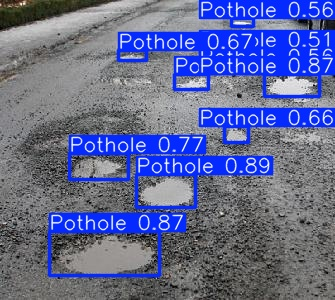

File: img-663_jpg.rf.eacecce4c5b4615ad0dbe455777e1547.jpg



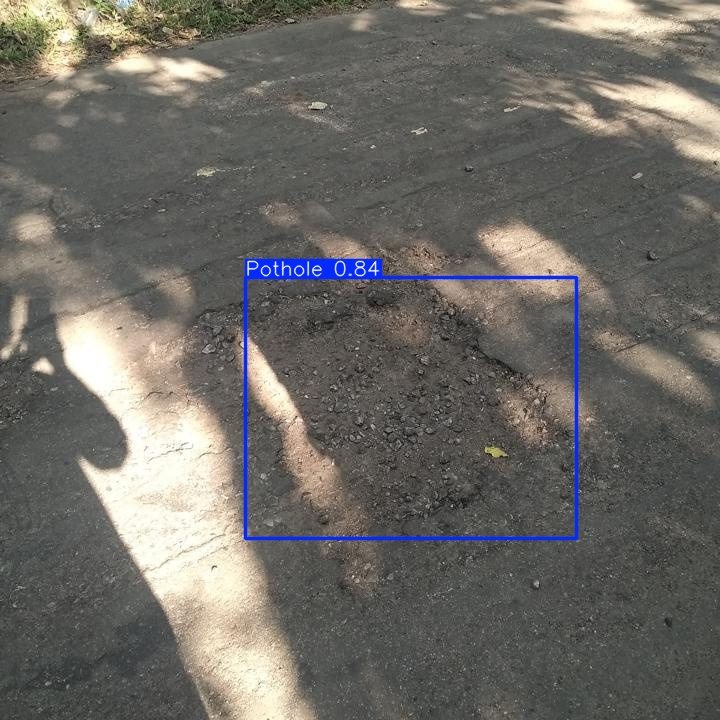

File: img-4_jpg.rf.11ae6e7fa2785e9062e1dd8c234333d9.jpg



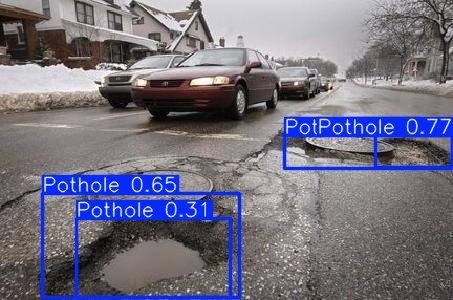

File: img-341_jpg.rf.7e6dcbcdf1805587819dc6cdcab56ac6.jpg



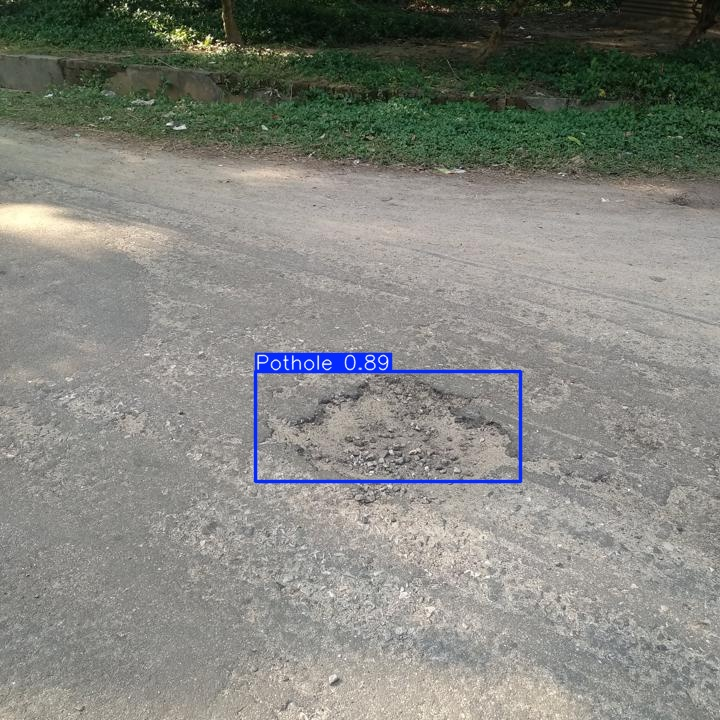

File: img-174_jpg.rf.63afee69864babbb4a21a4b8d2eff7d9.jpg



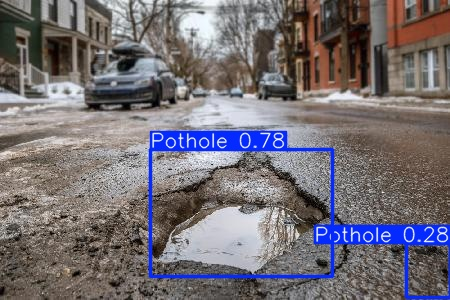

File: img-412_jpg.rf.c3344901cc1646179c93d2e8cd1b4444.jpg



In [17]:
import glob
import os
from IPython.display import Image, display

# Find the most recent prediction folder
predict_folders = glob.glob('/content/runs/detect/predict*/')
if predict_folders:
    latest_folder = max(predict_folders, key=os.path.getmtime)
    print(f"Showing results from: {latest_folder}")

    # Display up to 5 images to check quality
    images = glob.glob(os.path.join(latest_folder, '*.jpg')) + glob.glob(os.path.join(latest_folder, '*.png'))
    for image_path in images[:5]:
        display(Image(filename=image_path, width=600))
        print(f"File: {os.path.basename(image_path)}\n")
else:
    print("No prediction folders found! Make sure the 'yolo detect predict' command finished.")

Download YOLO Model

In [19]:
!mkdir -p /content/my_model

!cp /content/runs/detect/train/weights/best.pt /content/my_model/pothole_best_weights.pt

!cp -r /content/runs/detect/train /content/my_model/train_results

!cp /content/data.yaml /content/my_model/data.yaml

!zip -r /content/pothole_model_package.zip /content/my_model

updating: content/my_model/ (stored 0%)
  adding: content/my_model/train_results/ (stored 0%)
  adding: content/my_model/train_results/BoxP_curve.png (deflated 16%)
  adding: content/my_model/train_results/train_batch812.jpg (deflated 4%)
  adding: content/my_model/train_results/val_batch0_pred.jpg (deflated 9%)
  adding: content/my_model/train_results/val_batch1_labels.jpg (deflated 6%)
  adding: content/my_model/train_results/BoxR_curve.png (deflated 15%)
  adding: content/my_model/train_results/labels.jpg (deflated 34%)
  adding: content/my_model/train_results/args.yaml (deflated 53%)
  adding: content/my_model/train_results/val_batch1_pred.jpg (deflated 6%)
  adding: content/my_model/train_results/weights/ (stored 0%)
  adding: content/my_model/train_results/weights/best.pt (deflated 8%)
  adding: content/my_model/train_results/weights/last.pt (deflated 8%)
  adding: content/my_model/train_results/BoxPR_curve.png (deflated 21%)
  adding: content/my_model/train_results/results.csv (

In [20]:
from google.colab import files
files.download('/content/pothole_model_package.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>